Memunculkan Data


In [33]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
display(df.head(3))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


Show data columns 

In [6]:
for col in df.columns:
    print(col)

show_id
type
title
director
cast
country
date_added
release_year
rating
duration
listed_in
description


ANALISIS DATA

In [7]:
print("Missing Values", df.isna().sum())

Missing Values show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [12]:
print("data duplicates", df.duplicated().sum())

data duplicates 0


In [ ]:
print("tipe data",df.info())
#rating harus dibenerin atau di pisahin antara int dan string

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
tipe data None


In [ ]:

mask = df.astype(str).apply(lambda x: x.str.contains('ERROR', case=False, na=False))
print(mask.sum()) 

show_id           0
type              0
title             4
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description     107
dtype: int64


In [24]:
mask = df.astype(str).apply(lambda x: x.str.contains('UNKNOW', case=False, na=False))
print(mask.sum()) 

show_id          0
type             0
title            8
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description     20
dtype: int64


In [ ]:

anomali_unknown = df[df['title'].str.contains('UNKNOW', case=False, na=False) | df['description'].str.contains('UNKNOW', case=False, na=False)]
display(anomali_unknown[['title', 'description']])

,title,description
12,Je Suis Karl,After most of her family is murdered in a terr...
461,The Unknown Saint,"Following a stint behind bars, a thief returns..."
865,Sabotage,A crack team of DEA agents plots a daring heis...
946,Stargate,An Egyptologist joins a mission into the unkno...
1279,Made You Look: A True Story About Fake Art,A woman walks into a New York gallery with a c...
1303,The Most Unknown,Traversing disciplines from physics to psychol...
1467,Unknown,Liam Neeson stars as a man who regains conscio...
1573,The Expanding Universe of Ashley Garcia,15-year-old scientist Ashley Garcia explores t...
2088,Unknown Origins,A very chiseled but somber detective must find...
2455,The Stolen,A well-to-do British woman must venture into N...


In [31]:
print("UNKNOWN VALUES", (df== 'UNKNOWN').sum().sum()) 
print("ERROR VALUES", (df== 'ERROR').sum().sum())
print("null VALUES", (df== 'null').sum().sum())
print("? VALUES", (df== '?').sum().sum())

UNKNOWN VALUES 0
ERROR VALUES 0
null VALUES 0
? VALUES 0


In [32]:
print("data unik di setiap column rating:",(df['rating'].unique()))





data unik di setiap column rating: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


In [23]:
print("data unik di setiap type:",(df['type'].unique()))
print("data unik di setiap column release_year:",(df['release_year'].unique()))

data unik di setiap type: ['Movie' 'TV Show']
data unik di setiap column release_year: [2020 2021 1993 2018 1996 1998 1997 2010 2013 2017 1975 1978 1983 1987
 2012 2001 2014 2002 2003 2004 2011 2008 2009 2007 2005 2006 1994 2015
 2019 2016 1982 1989 1990 1991 1999 1986 1992 1984 1980 1961 2000 1995
 1985 1976 1959 1988 1981 1972 1964 1945 1954 1979 1958 1956 1963 1970
 1973 1925 1974 1960 1966 1971 1962 1969 1977 1967 1968 1965 1946 1942
 1955 1944 1947 1943]


masalah - masalah yang ada : 
1.menyelesaikan isna 
2.menyelesaikan type data column rating yang mana harus di pisahkan integer sendiri dan string sendiri
3.menyelesaikan data rating yang kemasukan data durasi


CLEAN UP DATA

In [6]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [7]:
print("Sisa Missing Values setelah di-fillna:")
print(df[['director', 'cast', 'country']].isna().sum())

Sisa Missing Values setelah di-fillna:
director    0
cast        0
country     0
dtype: int64


In [8]:
rating_nyasar = df[df['rating'].astype(str).str.contains('min|Season', case=False, na=False)]
display(rating_nyasar[['title', 'rating', 'duration']])

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [ ]:

mask = df['rating'].astype(str).str.contains('min|Season', case=False, na=False)

df.loc[mask, 'duration'] = df.loc[mask, 'rating']

df.loc[mask, 'rating'] = pd.NA

setelah di pindah data 

In [16]:
rating_nyasar = df[df['rating'].astype(str).str.contains('min|Season', case=False, na=False)]
display(rating_nyasar[['title', 'rating', 'duration']])

,title,rating,duration


menampilkan isi column rating yang data nya kosong

In [ ]:

rating_kosong = df[df['rating'].isna()]
display(rating_kosong[['title', 'type', 'rating', 'duration']])

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,<NA>,74 min
5794,Louis C.K.: Hilarious,Movie,<NA>,84 min
5813,Louis C.K.: Live at the Comedy Store,Movie,<NA>,66 min
5989,13TH: A Conversation with Oprah Winfrey & Ava ...,Movie,NaN,37 min
6827,Gargantia on the Verdurous Planet,TV Show,NaN,1 Season
7312,Little Lunch,TV Show,NaN,1 Season
7537,My Honor Was Loyalty,Movie,NaN,115 min


memperbaiki nilai kosong pada column rating

In [19]:
df['rating'] = df['rating'].fillna('Unknown')

menampilkan data kosong pada column date_added

In [21]:

rating_kosong = df[df['date_added'].isna()]
display(rating_kosong[['title', 'type','date_added', 'rating', 'duration']])

,title,type,date_added,rating,duration
6066,A Young Doctor's Notebook and Other Stories,TV Show,NaN,TV-MA,2 Seasons
6174,Anthony Bourdain: Parts Unknown,TV Show,NaN,TV-PG,5 Seasons
6795,Frasier,TV Show,NaN,TV-PG,11 Seasons
6806,Friends,TV Show,NaN,TV-14,10 Seasons
6901,Gunslinger Girl,TV Show,NaN,TV-14,2 Seasons
7196,Kikoriki,TV Show,NaN,TV-Y,2 Seasons
7254,La Familia P. Luche,TV Show,NaN,TV-14,3 Seasons
7406,Maron,TV Show,NaN,TV-MA,4 Seasons
7847,Red vs. Blue,TV Show,NaN,NR,13 Seasons
8182,The Adventures of Figaro Pho,TV Show,NaN,TV-Y7,2 Seasons


memperbaiki data kosong pada column date_added

In [22]:
df['date_added'] = df['date_added'].fillna('Unknown')

cek apakah masih ada data kotor


In [23]:
print("cek data kotor", df.isna().sum())

cek data kotor show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


cek data duplicated


In [28]:
print("data duplicated:",df.duplicated().sum())

data duplicated: 0


In [ ]:
df.to_csv('netflix_cleaned(josjis).csv', index=False)

Visualisasi top 10 negara dengan produsen terbanyak

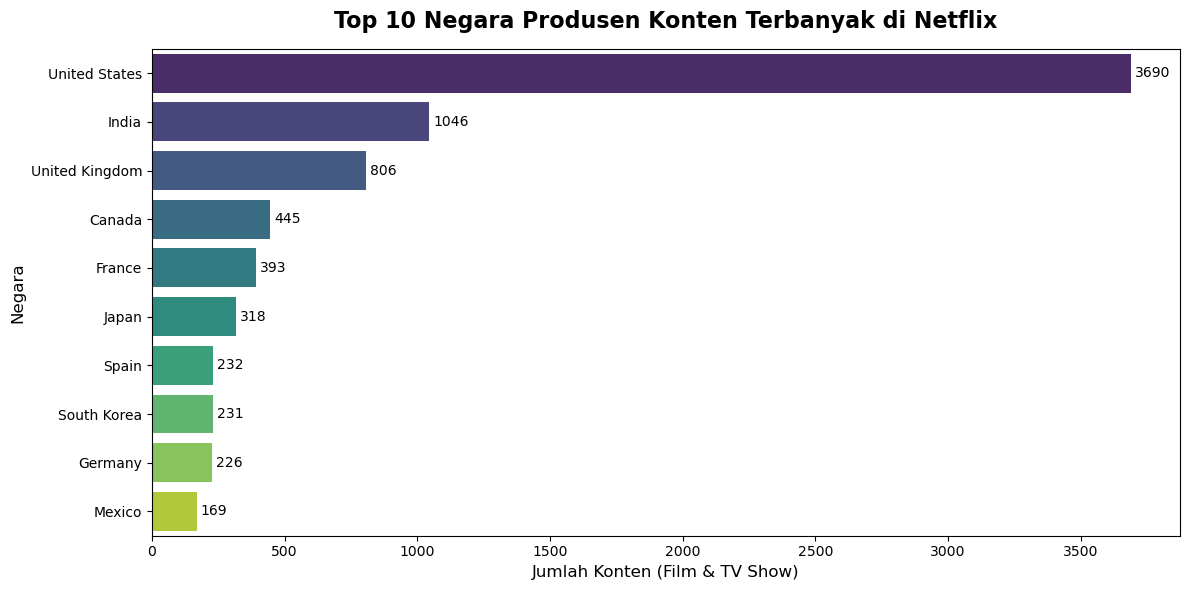

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('netflix_cleaned(josjis).csv')


top_countries = df['country'].dropna().str.split(',').explode().str.strip()


top_countries = top_countries[top_countries != 'Unknown']


top_10 = top_countries.value_counts().head(10)


plt.figure(figsize=(12, 6))
sns.barplot(x=top_10.values, y=top_10.index, palette='viridis', hue=top_10.index, legend=False)

plt.title('Top 10 Negara Produsen Konten Terbanyak di Netflix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jumlah Konten (Film & TV Show)', fontsize=12)
plt.ylabel('Negara', fontsize=12)


for index, value in enumerate(top_10.values):
    plt.text(value + 15, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

HeatMap korelasi berdasarkan rating usia dengan type Movie/Tv Show

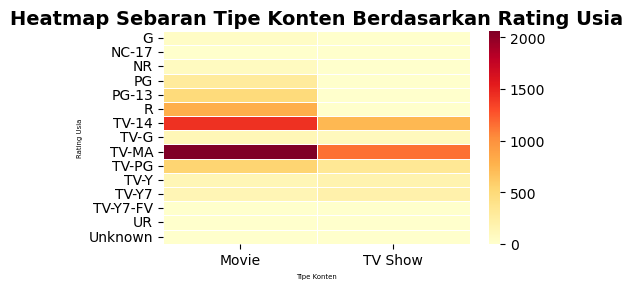

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('netflix_cleaned(josjis).csv')

heatmap_data = pd.crosstab(df['rating'], df['type'])

plt.figure(figsize=(5, 3))
sns.heatmap(heatmap_data, annot=False, fmt='d', cmap='YlOrRd', linewidths=.5)

plt.title('Heatmap Sebaran Tipe Konten Berdasarkan Rating Usia', fontsize=14, fontweight='bold', pad=5)
plt.xlabel('Tipe Konten', fontsize=5)
plt.ylabel('Rating Usia', fontsize=5)

plt.tight_layout()
plt.show()

Grafik Tren Perkembangan Jumlah Rilis Konten Netflix per Tahun

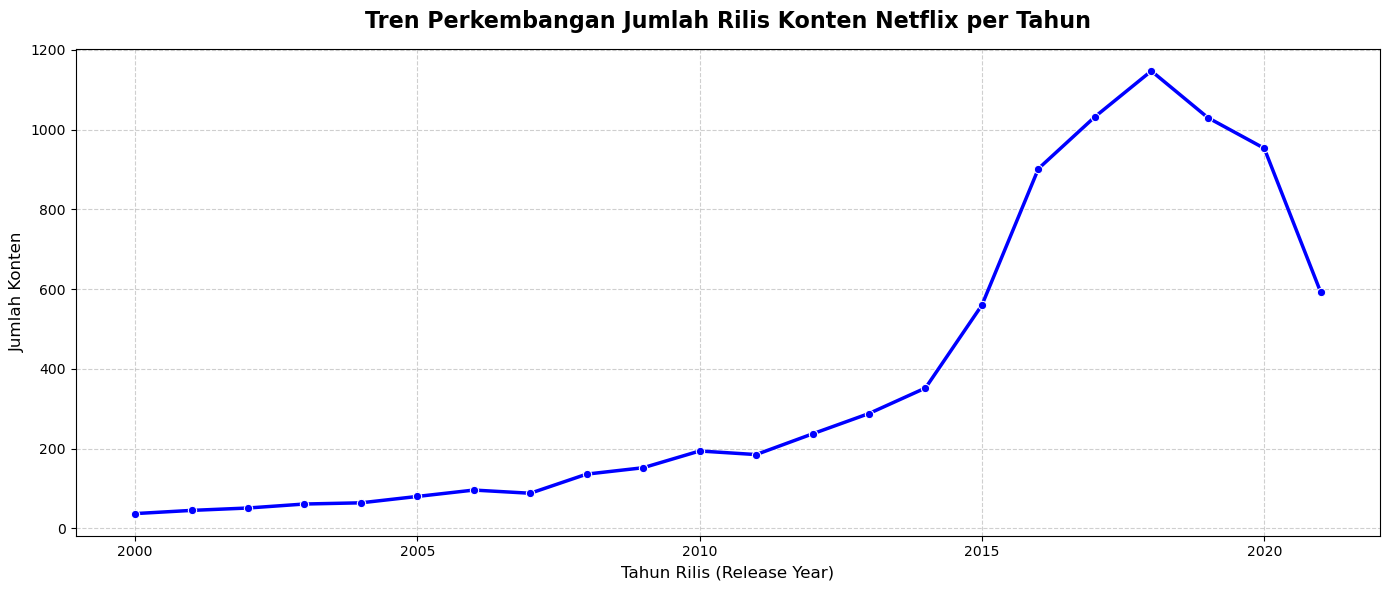

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('netflix_cleaned(josjis).csv')

yearly_trend = df['release_year'].value_counts().sort_index()


yearly_trend = yearly_trend[yearly_trend.index >= 2000]


plt.figure(figsize=(14, 6))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o', color='b', linewidth=2.5)


plt.title('Tren Perkembangan Jumlah Rilis Konten Netflix per Tahun', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tahun Rilis (Release Year)', fontsize=12)
plt.ylabel('Jumlah Konten', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()